# Classification Binaire : Photo vs Non-Photo

##  Groupe B : 
- FAURE ANTOINE
- GACHITA ZIED
- HOUILLE LUKAS 
- CORNU THEODORE

Ce notebook guide pas à pas la création d'un pipeline **deep learning** capable de distinguer les photos réelles des images non-photo (dessins, infographies, schémas, etc.).

##  Objectifs du notebook
- Préparer et prétraiter les données d'entraînement à partir d'une arborescence sur disque.
- Concevoir un **CNN sur mesure** adapté à un petit jeu de données.
- Entraîner et évaluer le modèle avec des métriques détaillées et des visualisations.
- Tester le classifieur sur des images individuelles pour un contrôle manuel.

##  Plan des sections
1. Importation des dépendances et configuration de l'environnement.
2. Chargement, prétraitement et accélération des jeux de données.
3. Construction du modèle CNN avec régularisation.
4. Stratégies d'entraînement (callbacks, scheduler).
5. Visualisation des courbes d'apprentissage.
6. Évaluation automatisée (matrice de confusion & métriques).
7. Tests manuels sur images unitaires.
8. Analyse biais/variance.
9. Pistes d'amélioration.
10. Conclusion & prochaines étapes.

##  Importation des librairies
Nous chargeons TensorFlow / Keras pour le deep learning, `matplotlib` et `numpy` pour l'analyse et la visualisation, ainsi que `Path` pour gérer les chemins de fichiers de manière robuste. Des paramètres globaux sont aussi fixés pour assurer la reproductibilité.

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Fixation de la graine aléatoire pour rendre les expériences reproductibles
tf.keras.utils.set_random_seed(42)
# Active le mode de préchargement automatique pour les pipelines tf.data
AUTOTUNE = tf.data.AUTOTUNE


2025-10-17 08:50:56.858265: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 2️ Chargement et Prétraitement des Données
Cette section définit les constantes globales (taille des images, taille de lot, dossier racine) puis construit deux datasets TensorFlow à partir de l'arborescence disque.

Les opérations clés :
- découpage **train/validation** avec `validation_split` pour éviter les fuites de données ;
- redimensionnement des images au format attendu par le modèle ;
- `configure_dataset` qui met en cache, mélange (pour le train) et précharge (`prefetch`) pour optimiser l'I/O GPU.

 *Il faut s'assurer que la structure disque est `data/raw/<classe>/image.jpg` pour que la détection de classes fonctionne automatiquement.*

In [3]:
IMG_SIZE = 128
BATCH_SIZE = 32
DATA_ROOT = Path("data/raw").resolve()

if not DATA_ROOT.exists():
    raise FileNotFoundError(
        f"Le dossier de données attendu {DATA_ROOT} est introuvable."
    )

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_ROOT,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_ROOT,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
)

class_names = train_ds.class_names
print(f"Classes détectées: {class_names}")


def configure_dataset(dataset, training=False):
    dataset = dataset.cache()
    if training:
        dataset = dataset.shuffle(buffer_size=256, seed=42)
    return dataset.prefetch(buffer_size=AUTOTUNE)


train_ds = configure_dataset(train_ds, training=True)
val_ds = configure_dataset(val_ds)

Found 41398 files belonging to 2 classes.
Using 33119 files for training.
Using 33119 files for training.


I0000 00:00:1760691131.353192      27 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1765 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Found 41398 files belonging to 2 classes.
Using 8279 files for validation.
Using 8279 files for validation.
Classes détectées: ['non_photo', 'photo']
Classes détectées: ['non_photo', 'photo']


## 3️ Construction du Modèle CNN avec Régularisation
Nous assemblons ici un réseau de neurones convolutif léger, adapté à des images 128×128.

Étapes principales :
1. Data augmentation intégrée au modèle (flip, rotation, zoom) pour enrichir virtuellement les données.
2. Normalisation des pixels afin de stabiliser l'apprentissage.
3. Blocs convolutionnels maison (`conv_block`) avec régularisation L2 et BatchNorm pour éviter l'overfitting.
4. Dropout progressif et couche dense finale sigmoïde pour produire une probabilité de "photo".

 Aucun poids pré-entraîné n'est utilisé : le modèle apprend entièrement depuis zéro sur votre dataset.

In [4]:
# Pipeline de data augmentation exécuté sur le GPU lors de l'entraînement
data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
# miroir horizontal aléatoire
        layers.RandomRotation(0.08),
# petites rotations pour variabilité angulaire
        layers.RandomZoom(0.1),
# zoom in/out modéré
    ],
    name="data_augmentation",
)

# Mise à l'échelle des pixels de [0,255] vers [0,1]
pixel_normalization = layers.Rescaling(1.0 / 255.0, name="pixel_normalization")

reg = regularizers.l2(1e-4)
# régularisation L2 partagée sur toutes les couches convolutives

def conv_block(x, filters):
    """Bloc convolutionnel avec BatchNorm et pooling."""
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False, kernel_regularizer=reg)(x)
# première convolution
    x = layers.BatchNormalization()(x)
# normalisation pour stabiliser les gradients
    x = layers.Activation("relu")(x)
# non-linéarité
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False, kernel_regularizer=reg)(x)
# deuxième convolution pour enrichir les features
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    return layers.MaxPooling2D()(x)
# réduction spatiale pour capturer le contexte

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
# augmentations uniquement en mode entraînement
x = pixel_normalization(x)
# remise à l'échelle des pixels
x = conv_block(x, 32)
x = layers.Dropout(0.2)(x)
# dropout léger sur les premières features
x = conv_block(x, 64)
x = layers.Dropout(0.3)(x)
x = conv_block(x, 128)
x = layers.Dropout(0.4)(x)
x = layers.Conv2D(256, 3, padding="same", activation="relu", kernel_regularizer=reg)(x)
# couche conv finale sans pooling
x = layers.GlobalAveragePooling2D()(x)
# moyennage spatial pour limiter le nombre de paramètres
x = layers.Dense(128, activation="relu", kernel_regularizer=reg)(x)
# projection dense finale
x = layers.Dropout(0.4)(x)
# dropout avant la prédiction
outputs = layers.Dense(1, activation="sigmoid")(x)
# probabilité binaire (photo vs non-photo)

model = models.Model(inputs, outputs, name="photo_classifier_cnn")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
# Adam stable pour petites architectures
    loss="binary_crossentropy",
# adaptée aux probabilités sigmoïdes
    metrics=["accuracy"],
# suivi de l'accuracy en plus de la loss
)

model.summary()
# aperçu de l'architecture et du nombre de paramètres


Model: "photo_classifier_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pixel_normalization (Rescaling) │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 616,545 (2.35 MB)

 Trainable params: 615,649 (2.35 MB)

 Non-trainable params: 896 (3.50 KB)

##  Entraînement avec Early Stopping et Learning Rate Scheduler
Pour sécuriser l'entraînement, nous combinons deux callbacks :
- **EarlyStopping** : stoppe la formation lorsque la validation n'améliore plus, tout en restaurant les meilleurs poids.
- **ReduceLROnPlateau** : diminue automatiquement le learning rate si la val_loss stagne.

L'appel à `model.fit` orchestre l'entraînement sur 25 époques maximum avec suivi de la validation.

In [5]:
# Early stopping : stoppe l'entraînement si la validation n'améliore plus
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
# tolère 5 époques sans progrès
    restore_best_weights=True,
# recharge automatiquement les meilleurs poids
)

# Scheduler : réduit le LR quand la val_loss stagne
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
# multiplie le LR par 0.2
    patience=3,
# après 3 époques sans amélioration
    verbose=1,
# logue les ajustements
)

history = model.fit(
    train_ds,
# dataset d'entraînement
    epochs=25,
# maximum d'époques
    validation_data=val_ds,
# dataset de validation
    callbacks=[early_stop, lr_scheduler],
# stratégie d'entraînement
)


Epoch 1/25


E0000 00:00:1760691205.066285      27 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/photo_classifier_cnn_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2025-10-17 08:53:34.569560: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 90800
2025-10-17 08:53:34.569560: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 90800
2025-10-17 08:53:38.757952: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.21GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-10-17 08:53:38.757952: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.21GiB with fr

1035/1035 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.7927 - loss: 0.4394

2025-10-17 08:55:59.186289: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
Corrupt JPEG data: 419 extraneous bytes before marker 0xd9
Corrupt JPEG data: 419 extraneous bytes before marker 0xd9


1035/1035 ━━━━━━━━━━━━━━━━━━━━ 163s 141ms/step - accuracy: 0.8209 - loss: 0.4044 - val_accuracy: 0.8584 - val_loss: 0.3694 - learning_rate: 1.0000e-04
Epoch 2/25
Epoch 2/25
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 131s 127ms/step - accuracy: 0.8637 - loss: 0.3525 - val_accuracy: 0.8733 - val_loss: 0.3507 - learning_rate: 1.0000e-04
Epoch 3/25
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 131s 127ms/step - accuracy: 0.8637 - loss: 0.3525 - val_accuracy: 0.8733 - val_loss: 0.3507 - learning_rate: 1.0000e-04
Epoch 3/25
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 130s 126ms/step - accuracy: 0.8772 - loss: 0.3271 - val_accuracy: 0.8723 - val_loss: 0.3419 - learning_rate: 1.0000e-04
Epoch 4/25
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 130s 126ms/step - accuracy: 0.8772 - loss: 0.3271 - val_accuracy: 0.8723 - val_loss: 0.3419 - learning_rate: 1.0000e-04
Epoch 4/25
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 130s 126ms/step - accuracy: 0.8877 - loss: 0.3081 - val_accuracy: 0.8687 - val_loss: 0.3541 - learning_rate: 1.0000e-04
1035/1035 ━━━━━━━━━━━━━━━━━━

##  Visualisation des Courbes d’Entraînement
Après l'entraînement, nous observons l'évolution de la perte et de l'accuracy pour détecter d'éventuels problèmes (overfitting, plateau prématuré).
- Le premier graphique compare la perte train vs validation.
- Le second affiche l'accuracy correspondante.

Ces visualisations aident à décider de nouvelles itérations (data augmentation, tuning d'hyperparamètres, etc.).

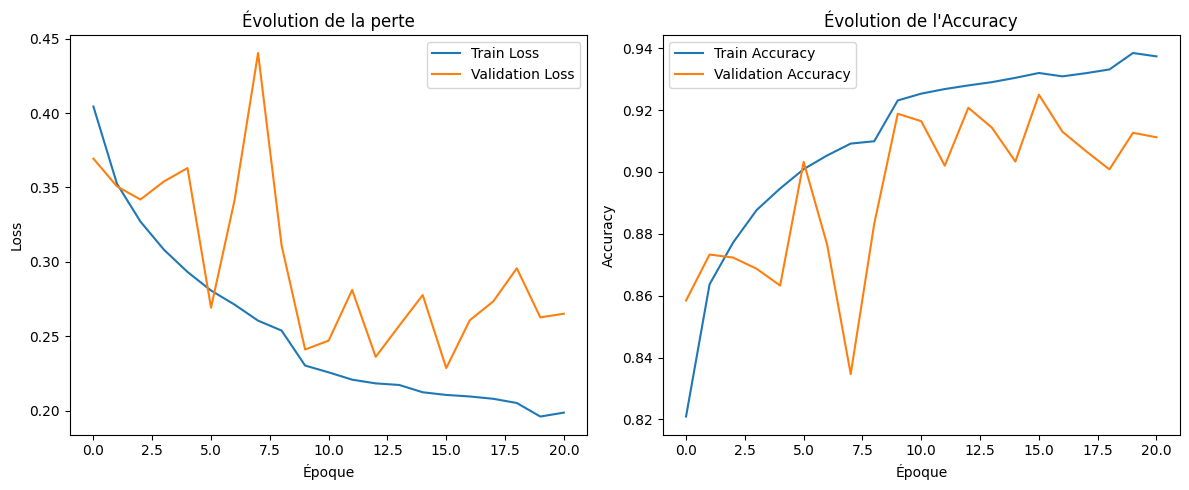

In [6]:
plt.figure(figsize=(12,5))
# figure 1x2
plt.subplot(1,2,1)
# courbe des pertes
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Évolution de la perte')
plt.xlabel('Époque')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
# courbe des accuracies
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Évolution de l'Accuracy")
plt.xlabel('Époque')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()


##  Évaluation sur le jeu de validation
Nous mesurons la performance du modèle sur le dataset de validation : distribution des prédictions, matrice de confusion, métriques de classification (Accuracy, Précision, Recall, F1) et aperçu visuel des images correctement/mal classées.

Cette étape confirme la robustesse du modèle avant de le déployer sur des données inédites.

2025-10-17 09:39:39.866008: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


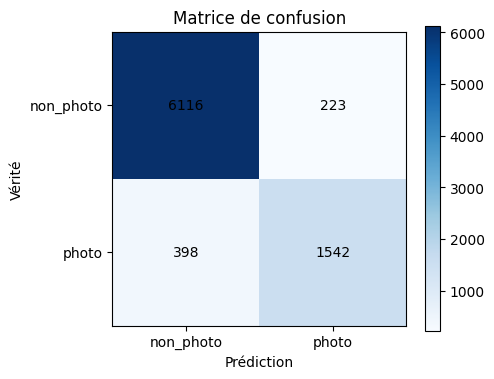

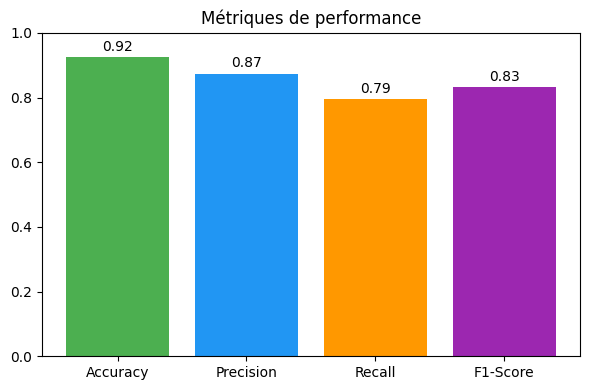

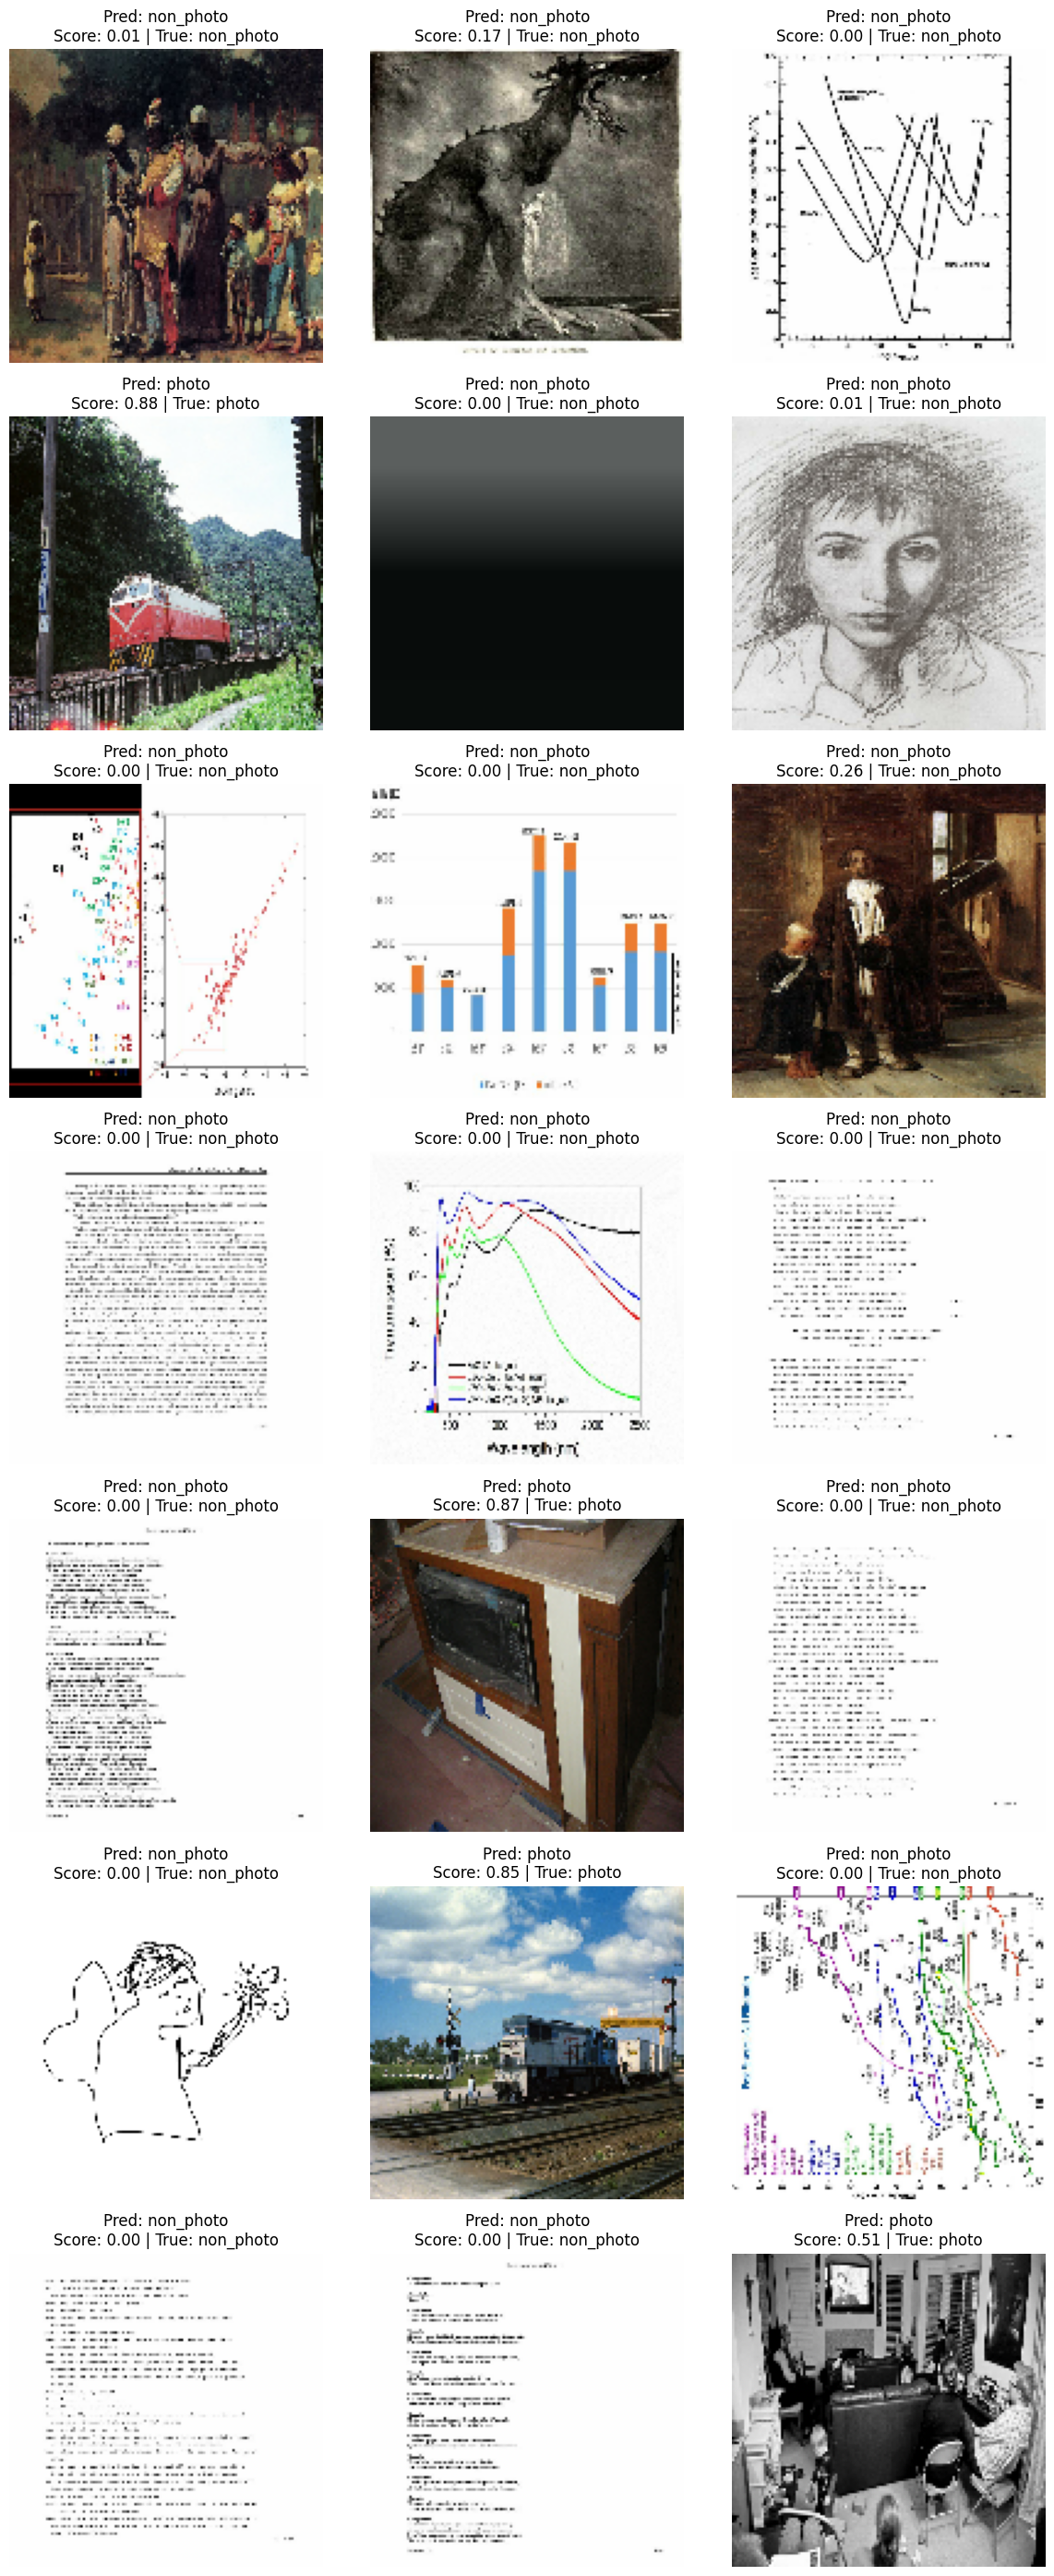

In [7]:
val_true = []
# étiquettes ground truth
val_scores = []
# scores sigmoïde bruts
sample_images = []
# images enregistrées pour affichage
sample_labels = []
# labels associés
sample_scores = []
# scores associés

for batch_images, batch_labels in val_ds:
# parcours des batches de validation
    batch_preds = model.predict(batch_images, verbose=0).squeeze()
# inference vectorisée
    val_scores.extend(np.atleast_1d(batch_preds).tolist())
    val_true.extend(batch_labels.numpy().tolist())
    if len(sample_images) < 6:
# on garde jusqu'à 6 exemples
        remaining = 6 - len(sample_images)
        take = min(remaining, batch_images.shape[0])
        if take > 0:
            sample_images.append(batch_images[:take].numpy())
            sample_labels.append(batch_labels[:take].numpy())
            sample_scores.append(np.atleast_1d(batch_preds)[:take])

has_samples = len(sample_images) > 0
# état (True/False) pour l'affichage
if has_samples:
    sample_images = np.concatenate(sample_images, axis=0)
    sample_labels = np.concatenate(sample_labels, axis=0)
    sample_scores = np.concatenate(sample_scores, axis=0)

val_true = np.array(val_true)
val_scores = np.array(val_scores)
val_pred_labels = (val_scores >= 0.5).astype(int)
# seuil de décision 0.5

conf_matrix = tf.math.confusion_matrix(val_true, val_pred_labels, num_classes=2).numpy()
tn, fp, fn, tp = conf_matrix.ravel().astype(np.float32)

metrics = {
    "Accuracy": (tp + tn) / max(tn + fp + fn + tp, 1.0),
# proportion de bonnes prédictions
    "Precision": tp / max(tp + fp, 1.0),
# fiabilité des positifs
    "Recall": tp / max(tp + fn, 1.0),
# couverture des positifs
}
metrics["F1-Score"] = 2 * metrics["Precision"] * metrics["Recall"] / max(metrics["Precision"] + metrics["Recall"], 1e-8)
# moyenne harmonique

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(conf_matrix, cmap="Blues")
ax.set_title("Matrice de confusion")
ax.set_xlabel("Prédiction")
ax.set_ylabel("Vérité")
ax.set_xticks([0, 1], labels=class_names)
ax.set_yticks([0, 1], labels=class_names)
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        ax.text(j, i, int(conf_matrix[i, j]), ha="center", va="center", color="black")
# annotation cellule par cellule
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(metrics.keys(), metrics.values(), color=["#4caf50", "#2196f3", "#ff9800", "#9c27b0"])
plt.ylim(0, 1)
plt.title("Métriques de performance")
for idx, value in enumerate(metrics.values()):
    plt.text(idx, value + 0.02, f"{value:.2f}", ha="center")
# annotation des barres
plt.tight_layout()
plt.show()

if has_samples:
    cols = 3
    rows = int(np.ceil(sample_images.shape[0] / cols))
    plt.figure(figsize=(12, 4 * rows))
    for idx in range(sample_images.shape[0]):
        ax = plt.subplot(rows, cols, idx + 1)
        ax.imshow(np.clip(sample_images[idx], 0, 255).astype("uint8"))
        pred_label = class_names[int(sample_scores[idx] >= 0.5)]
        true_label = class_names[int(sample_labels[idx])]
        ax.set_title(f"Pred: {pred_label}\nScore: {sample_scores[idx]:.2f} | True: {true_label}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

##  Tests manuels sur des images individuelles
Pour aller au-delà des métriques globales, nous testons manuellement quelques images. Cette cellule :
- propose une liste de chemins personnalisables ;
- récupère automatiquement des exemples si ces chemins n'existent pas ;
- affiche le score du modèle, la classe prédite et la vérité terrain pour chaque image.

Cela permet une validation qualitative rapide ("est-ce que les résultats semblent cohérents").

⚠️ Les chemins par défaut ne sont pas valides. Sélection automatique d'exemples.
[{'chemin': 'non_photo/000_1_1_sz1.jpg',
  'classe_attendue': 'non_photo',
  'classe_predite': 'non_photo',
  'image': '000_1_1_sz1.jpg',
  'score_photo': 0.001044173608534038},
 {'chemin': 'photo/photo_0001.jpg',
  'classe_attendue': 'photo',
  'classe_predite': 'photo',
  'image': 'photo_0001.jpg',
  'score_photo': 0.7861326932907104}]
[{'chemin': 'non_photo/000_1_1_sz1.jpg',
  'classe_attendue': 'non_photo',
  'classe_predite': 'non_photo',
  'image': '000_1_1_sz1.jpg',
  'score_photo': 0.001044173608534038},
 {'chemin': 'photo/photo_0001.jpg',
  'classe_attendue': 'photo',
  'classe_predite': 'photo',
  'image': 'photo_0001.jpg',
  'score_photo': 0.7861326932907104}]


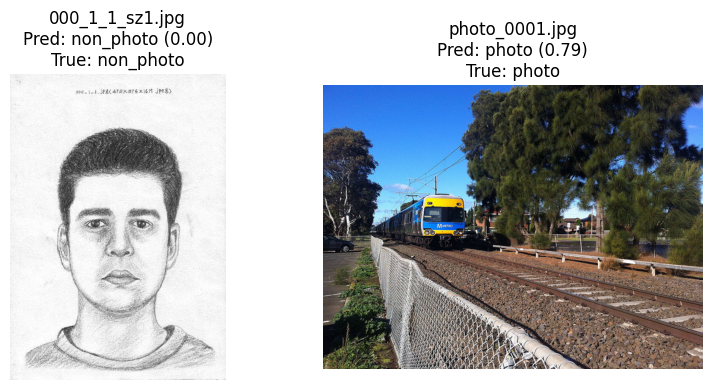

In [8]:
from pathlib import Path
# garde-fou si la cellule est exécutée seule
from tensorflow.keras.utils import load_img, img_to_array
from pprint import pprint
%matplotlib inline


DATA_ROOT = Path("data/raw").resolve()
if not DATA_ROOT.exists():
    raise FileNotFoundError(
        f"Le dossier de données attendu {DATA_ROOT} est introuvable."
    )
# ❗️ Modifiez cette liste pour tester d'autres images manuellement
test_image_paths = [
    DATA_ROOT / class_names[0] / "photo_9999.jpg",
# exemple volontairement invalide pour déclencher la sélection auto
    DATA_ROOT / class_names[-1] / "Wp-059-1-sz1.jpg",
# exemple dans l'autre classe
]

auto_paths = []
# contiendra les premières images valides de chaque classe
for class_name in class_names:
    class_dir = (DATA_ROOT / class_name)
    if class_dir.is_dir():
        for candidate in sorted(class_dir.glob("*")):
            if candidate.suffix.lower() in {".jpg", ".jpeg", ".png"}:
                auto_paths.append(candidate)
# stocke la première image trouvée dans cette classe
                break

if not any(path.exists() for path in test_image_paths):
    print("⚠️ Les chemins par défaut ne sont pas valides. Sélection automatique d'exemples.")
    test_image_paths = auto_paths[:6]
# fallback : premières images détectées

results = []
# dictionnaire des prédictions
figures = []
# tuples pour l'affichage graphique

for path in test_image_paths:
    if not path.exists():
        print(f"[SKIP] Fichier introuvable: {path}")
        continue

    original_img = load_img(path)
# version pleine résolution pour l'affichage
    resized_img = load_img(path, target_size=(IMG_SIZE, IMG_SIZE))
# version redimensionnée pour le modèle
    img_array = img_to_array(resized_img)
# conversion en tenseur numpy
    score = float(model.predict(img_array[None, ...], verbose=0)[0][0])
# inference sur une seule image
    pred_label = class_names[int(score >= 0.5)]
# mapping probabilité -> label
    true_label = path.parent.name
# label attendu issu du dossier
    results.append({
        "image": path.name,
        "chemin": str(path.relative_to(DATA_ROOT)),
        "classe_attendue": true_label,
        "score_photo": score,
        "classe_predite": pred_label,
    })
    figures.append((path.name, np.array(original_img), score, pred_label, true_label))

if not results:
    raise RuntimeError("Aucune image valide n'a été trouvée. Mettez à jour test_image_paths avec des chemins existants.")

pprint(results)
# affiche les résultats bruts

cols = 3
rows = int(np.ceil(len(figures) / cols)) or 1
# garantit au moins une ligne
plt.figure(figsize=(12, 4 * rows))
for idx, (name, image, score, pred, true) in enumerate(figures, start=1):
    ax = plt.subplot(rows, cols, idx)
    ax.imshow(image)
    ax.set_title(f"{name}\nPred: {pred} ({score:.2f})\nTrue: {true}")
    ax.axis("off")
plt.tight_layout()
plt.show()

##  Analyse Biais / Variance
Cette section rappelle comment interpréter les courbes de perte/accuracy :
- val_loss ≫ train_loss : le modèle sur-apprend (variance élevée). Il faut renforcer la régularisation ou collecter plus de données.
- train_loss élevée + val_loss élevée : sous-apprentissage (biais). Un modèle plus riche ou un apprentissage plus long peut être nécessaire.

Ces heuristiques servent de guide pour choisir la prochaine expérimentation.

##  Améliorations Possibles
Quelques pistes pour améliorer davantage le classifieur :
- Fine-tuning : dégeler certaines couches des blocs convolutionnels pour affiner l'extraction de caractéristiques.
- Dropout dynamique : ajuster les probabilités de dropout au fil de l'entraînement.
- Data augmentation avancée : ajouter transformations de couleur, bruit, flou, etc., pour améliorer la robustesse.
- Batch Normalization : déjà utilisée dans les blocs conv, mais peut aussi être expérimentée après la couche dense finale.
- Optimisation des hyperparamètres : grid-search ou Bayesian optimisation sur le learning rate, le nombre de filtres, la profondeur du réseau.

##  Conclusion & prochaines étapes
- Résultats : le modèle CNN personnalisé fournit une baseline fonctionnelle pour distinguer photos et non-photos, avec une évaluation complète (métriques, visualisations).
- Forces : pipeline reproductible, augmentation intégrée, callbacks de régularisation, tests manuels rapides.
- Limites : dataset relativement petit, architecture encore simple, absence de tests unitaires / déploiement.

## 💾 Sauvegarde du modèle et des artefacts

Cette section enregistre le modèle entraîné, ses poids, la liste des classes, l'historique d'entraînement et les métriques d'évaluation dans le dossier `outputs/`.

- Génère des noms de fichiers horodatés pour la traçabilité.
- Crée également une copie « latest » pour un accès rapide au dernier modèle.

Exécutez cette cellule après l'entraînement pour persister vos résultats.

In [9]:
from pathlib import Path
import json
from datetime import datetime

# Contrat:
# - Entrées: `model`, `history`, `class_names`, `val_ds`
# - Sorties: fichiers dans outputs/
#   * model_<timestamp>.keras + model_latest.keras
#   * weights_<timestamp>.weights.h5 + weights_latest.weights.h5
#   * class_names.json
#   * history_<timestamp>.json
#   * val_metrics_<timestamp>.json

outputs_dir = Path("outputs")
outputs_dir.mkdir(parents=True, exist_ok=True)

# Timestamp pour versionner
stamp = datetime.now().strftime("%Y%m%d-%H%M%S")

# 1) Sauvegarde du modèle complet (architecture + poids + optimizer state)
model_path_ts = outputs_dir / f"photo_classifier_{stamp}.keras"
model_path_latest = outputs_dir / "photo_classifier_latest.keras"
model.save(model_path_ts)
model.save(model_path_latest)
print(f"✅ Modèle enregistré: {model_path_ts.name} et {model_path_latest.name}")

# 2) Sauvegarde des poids uniquement (optionnel, pratique pour chargement rapide)
weights_path_ts = outputs_dir / f"photo_classifier_weights_{stamp}.weights.h5"
weights_path_latest = outputs_dir / "photo_classifier_weights_latest.weights.h5"
model.save_weights(weights_path_ts)
model.save_weights(weights_path_latest)
print(f"✅ Poids enregistrés: {weights_path_ts.name} et {weights_path_latest.name}")

# 3) Sauvegarde des classes détectées
classes_path = outputs_dir / "class_names.json"
with classes_path.open("w", encoding="utf-8") as f:
    json.dump({"class_names": class_names}, f, ensure_ascii=False, indent=2)
print(f"✅ Classes enregistrées: {classes_path.name} -> {class_names}")

# 4) Historique d'entraînement
history_path = outputs_dir / f"history_{stamp}.json"
hist_dict = {k: list(map(float, v)) for k, v in getattr(history, 'history', {}).items()}
with history_path.open("w", encoding="utf-8") as f:
    json.dump(hist_dict, f, ensure_ascii=False, indent=2)
print(f"✅ Historique enregistré: {history_path.name}")

# 5) Évaluation finale sur le set de validation (loss & accuracy)
val_metrics_path = outputs_dir / f"val_metrics_{stamp}.json"
try:
    eval_vals = model.evaluate(val_ds, return_dict=True, verbose=0)
except TypeError:
    # Keras < 2.13 ne supporte pas return_dict
    eval_list = model.evaluate(val_ds, verbose=0)
    # map naive des noms de metrics depuis model.metrics_names
    eval_vals = {name: float(val) for name, val in zip(model.metrics_names, eval_list)}

with val_metrics_path.open("w", encoding="utf-8") as f:
    json.dump({k: float(v) for k, v in eval_vals.items()}, f, ensure_ascii=False, indent=2)
print(f"✅ Métriques de validation enregistrées: {val_metrics_path.name} -> {eval_vals}")

print("💡 Chargement ultérieur:")
print("- Modèle complet: tf.keras.models.load_model('outputs/photo_classifier_latest.keras')")
print("- Poids seuls: model.load_weights('outputs/photo_classifier_weights_latest.weights.h5')")

✅ Modèle enregistré: photo_classifier_20251017-093943.keras et photo_classifier_latest.keras
✅ Poids enregistrés: photo_classifier_weights_20251017-093943.weights.h5 et photo_classifier_weights_latest.weights.h5
✅ Classes enregistrées: class_names.json -> ['non_photo', 'photo']
✅ Historique enregistré: history_20251017-093943.json
✅ Poids enregistrés: photo_classifier_weights_20251017-093943.weights.h5 et photo_classifier_weights_latest.weights.h5
✅ Classes enregistrées: class_names.json -> ['non_photo', 'photo']
✅ Historique enregistré: history_20251017-093943.json
✅ Métriques de validation enregistrées: val_metrics_20251017-093943.json -> {'accuracy': 0.9249909520149231, 'loss': 0.22861485183238983}
💡 Chargement ultérieur:
- Modèle complet: tf.keras.models.load_model('outputs/photo_classifier_latest.keras')
- Poids seuls: model.load_weights('outputs/photo_classifier_weights_latest.weights.h5')
✅ Métriques de validation enregistrées: val_metrics_20251017-093943.json -> {'accuracy': 0.

## 🔁 Utiliser le modèle dans un autre notebook

Cette section montre comment recharger le modèle enregistré depuis `outputs/` et l’utiliser pour prédire la classe d’une image.

- Charge en priorité le modèle complet `photo_classifier_latest.keras`.
- En fallback, reconstruit l’architecture et charge `photo_classifier_weights_latest.weights.h5`.
- Lit les `class_names` depuis `outputs/class_names.json`.

Vous pouvez copier-coller le code de la cellule suivante dans un autre notebook.

In [ ]:
# Exemple: rechargement et prédiction sur une image
import json
from pathlib import Path
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import load_img, img_to_array

outputs_dir = Path("outputs")
model_file = outputs_dir / "photo_classifier_latest.keras"
weights_file = outputs_dir / "photo_classifier_weights_latest.weights.h5"
classes_file = outputs_dir / "class_names.json"

# Charger les classes
if classes_file.exists():
    with classes_file.open("r", encoding="utf-8") as f:
        class_names = json.load(f)["class_names"]
else:
    raise FileNotFoundError("Fichier classes introuvable: outputs/class_names.json")

# 1) Essayer de charger le modèle complet
model = None
if model_file.exists():
    model = tf.keras.models.load_model(model_file)
    IMG_SIZE = model.input_shape[1]  # suppose (None, H, W, 3)
    print("✅ Modèle complet chargé.")
else:
    # 2) Fallback: reconstruire l'archi et charger uniquement les poids
    print("ℹ️ Modèle complet introuvable, tentative de chargement des poids...")
    IMG_SIZE = 128  # Ajuster si nécessaire

    # Récréer l'architecture minimale compatible
    from tensorflow.keras import layers, models, regularizers

    reg = regularizers.l2(1e-4)
    def conv_block(x, filters):
        x = layers.Conv2D(filters, 3, padding="same", use_bias=False, kernel_regularizer=reg)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        x = layers.Conv2D(filters, 3, padding="same", use_bias=False, kernel_regularizer=reg)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        return layers.MaxPooling2D()(x)

    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = layers.Rescaling(1.0/255.0)(inputs)  # Data aug. non nécessaire en inference
    x = conv_block(x, 32)
    x = layers.Dropout(0.2)(x)
    x = conv_block(x, 64)
    x = layers.Dropout(0.3)(x)
    x = conv_block(x, 128)
    x = layers.Dropout(0.4)(x)
    x = layers.Conv2D(256, 3, padding="same", activation="relu", kernel_regularizer=reg)(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu", kernel_regularizer=reg)(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])  # pour evaluate si besoin

    if weights_file.exists():
        model.load_weights(weights_file)
        print("✅ Poids chargés dans l'architecture reconstruite.")
    else:
        raise FileNotFoundError("Aucun modèle/poids trouvés dans outputs/.")


def predict_image(image_path: str, threshold: float = 0.5):
    """Retourne (score, label_pred, label_index)."""
    img = load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))
    arr = img_to_array(img)[None, ...]
    score = float(model.predict(arr, verbose=0)[0][0])
    label_idx = int(score >= threshold)
    label = class_names[label_idx]
    return score, label, label_idx

# Exemple d'utilisation (changer le chemin pour une vraie image locale)
example = None  # e.g., Path('data/raw/photo/xxx.jpg')

# Auto-sélection si non défini: prend la 1ère image disponible dans data/raw
if example is None:
    search_roots = [Path('data/raw/photo'), Path('data/raw/non_photo')]
    exts = ('*.jpg', '*.jpeg', '*.png')
    found = None
    for root in search_roots:
        if root.exists():
            for ext in exts:
                files = sorted(root.glob(ext))
                if files:
                    found = files[0]
                    break
        if found:
            break
    if found:
        example = found
        print(f"👉 Exemple auto-sélectionné: {example}")

if example and Path(example).exists():
    s, lbl, idx = predict_image(str(example))
    print(f"Pred: {lbl} (score={s:.2f})")
else:
    print("ℹ️ Définissez 'example' avec le chemin d'une image pour tester.")

✅ Modèle complet chargé.
👉 Exemple auto-sélectionné: data/raw/non_photo/000_1_1_sz1.jpg
Pred: non_photo (score=0.00)
